<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/StepDown_1stock_MC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plain Vanilla Put Option 평가하기

In [ ]:
!pip install hst_funcs

In [ ]:
# BS 공식에 의한 풋옵션 평가
from hst_funcs.finanace.Equity import BS

# 파라미터 설정
S0 = 100
K = 100
T = 1
r = 0.05
sigma = 0.3

opt0 = BS.bs_put(S0, K, T, r, sigma)
print('옵션 현재가치: ', opt0)

옵션 현재가치:  9.354197236057225


In [ ]:
# MC를 이용한 풋옵션 함수 작성

def MC_Put(S,K,T,r,sigma,n_sim=100000):
    import numpy as np
    # 난수 생성 (표준 정규분포)
    np.random.seed(11)
    Z = np.random.randn(n_sim)
    # 만기가격 도출
    ST = S * np.exp((r - 0.5 * sigma**2) * T\
                     + sigma * np.sqrt(T) * Z)
    # 풋옵션의 페이오프 계산
    payoff = np.maximum(K-ST, 0)
    # 현재가치 할인 적용 (할인율: e^(-rT))
    put_price = np.exp(-r * T) * np.mean(payoff)
    return put_price

In [ ]:
# 결과 출력
print(f"몬테카를로 시뮬레이션 기반 풋옵션 가격: " \
      f"{MC_Put(100, 100, 1, 0.05, 0.3):.4f}")
print(f"블랙숄즈 공식 기반 풋옵션 가격: " \
      f"{BS.bs_put(100,100,1,0.05,0.3):.4f}")

몬테카를로 시뮬레이션 기반 풋옵션 가격: 9.2751
블랙숄즈 공식 기반 풋옵션 가격: 9.3542


In [ ]:
def MC_Greeks(fun, S, K, T, r, sigma):
    # Delta (Δ)
    eps=S*sigma*0.01
    C_plus = fun(S + eps, K, T, r, sigma)
    C_minus = fun(S - eps, K, T, r, sigma)
    Delta = (C_plus - C_minus) / (2 * eps)
    # Gamma (Γ)
    C_0 = fun(S, K, T, r, sigma)
    Gamma = (C_plus - 2 * C_0 + C_minus) / (eps ** 2)
    # Vega (V)
    eps=sigma*0.01
    C_sigma_plus = fun(S, K, T, r, sigma + eps)
    C_sigma_minus = fun(S, K, T, r, sigma - eps)
    Vega = (C_sigma_plus - C_sigma_minus) / (2 * eps)
    Vega = 0.01*Vega # 1% 베가로 변환
    # 1day Theta (Θ)
    eps=0.01
    C_t = fun(S, K, T - eps, r, sigma)
    Theta = (1/365)*(C_t - C_0) / eps
    # 1bp Rho (ρ)
    C_r_plus = fun(S, K, T, r + eps, sigma)
    C_r_minus = fun(S, K, T, r - eps, sigma)
    Rho = 0.0001* (C_r_plus - C_r_minus) / (2 * eps)
    return {
        "Price": C_0,
        "Delta (Δ)": Delta,
        "Gamma (Γ)": Gamma,
        "Theta (Θ)": Theta,
        "Vega (V)": Vega,
        "Rho (ρ)": Rho,
    }

In [ ]:
res=MC_Greeks(MC_Put, 100, 100, 1, 0.05, 0.3)
res

{'Price': np.float64(9.275129383003724),
 'Delta (Δ)': np.float64(-0.37516958155066504),
 'Gamma (Γ)': np.float64(0.01162181001753816),
 'Theta (Θ)': np.float64(-0.009135373917150295),
 'Vega (V)': np.float64(0.3772682484415787),
 'Rho (ρ)': np.float64(-0.004678548225085866)}

In [ ]:
# Gamma (Γ)
Gamma=res["Gamma (Γ)"]
# 결과 출력
print(f"몬테카를로 시뮬레이션 기반 콜옵션 감마: {Gamma:.4f}")
print(f"블랙숄즈 공식 기반 콜옵션 감마: {BS.put_gamma(100,100,1,0.05,0.3):.4f}")

몬테카를로 시뮬레이션 기반 콜옵션 감마: 0.0116
블랙숄즈 공식 기반 콜옵션 감마: 0.0126


In [ ]:
# Vega (V)
Vega=res["Vega (V)"]

# 결과 출력
print(f"몬테카를로 시뮬레이션 기반 콜옵션 베가: {Vega:.4f}")
print(f"블랙숄즈 공식 기반 콜옵션 베가: {BS.put_vega(100,100,1,0.05,0.3):.4f}")

몬테카를로 시뮬레이션 기반 콜옵션 베가: 0.3773
블랙숄즈 공식 기반 콜옵션 베가: 0.3794


In [ ]:
# 1day Theta (Θ)
Theta=res["Theta (Θ)"]
# 결과 출력
print(f"몬테카를로 시뮬레이션 기반 콜옵션 세타: {Theta:.4f}")
print(f"블랙숄즈 공식 기반 콜옵션 세타: {BS.put_theta(100,100,1,0.05,0.3):.4f}")

몬테카를로 시뮬레이션 기반 콜옵션 세타: -0.0091
블랙숄즈 공식 기반 콜옵션 세타: -0.0092


In [ ]:
# 1bp Rho (ρ)
Rho=res["Rho (ρ)"]
# 결과 출력
print(f"몬테카를로 시뮬레이션 기반 콜옵션 르호: {Rho:.4f}")
print(f"블랙숄즈 공식 기반 콜옵션 르호: {BS.put_rho(100,100,1,0.05,0.3):.4f}")

몬테카를로 시뮬레이션 기반 콜옵션 르호: -0.0047
블랙숄즈 공식 기반 콜옵션 르호: -0.0047


## 1 Stock Step Down 상품 평가하기

In [3]:
# 오늘 날짜
from datetime import datetime
datetime.today()

datetime.datetime(2026, 1, 29, 0, 10, 54, 593349)

In [4]:
# 현재시각 설정
from datetime import datetime,timezone

# 날짜 이하의 숫자는 시, 분, 초, 마이크로초 정보임
datetime.now(timezone.utc) # 협정세계시 기준

datetime.datetime(2026, 1, 29, 0, 10, 55, 300393, tzinfo=datetime.timezone.utc)

In [5]:
# 대한민국 시각으로
from zoneinfo import ZoneInfo

dt = datetime.now(timezone.utc) # 협정세계시 기준
dt_kst = dt.astimezone(ZoneInfo("Asia/Seoul"))
dt_kst

datetime.datetime(2026, 1, 29, 9, 10, 56, 875677, tzinfo=zoneinfo.ZoneInfo(key='Asia/Seoul'))

In [6]:
# 날짜 정보까지만 추출
dt_kst.date()

datetime.date(2026, 1, 29)

In [7]:
# 오늘 날짜
import pandas as pd
today = pd.to_datetime(dt_kst.date())
six_months_later = today + pd.DateOffset(months=6)
today

Timestamp('2026-01-29 00:00:00')

In [8]:
# 주말 관계없이 6개월마다의 날짜 생성
import pandas as pd

D0=pd.date_range(six_months_later,periods=6,freq=pd.DateOffset(months=6))
# 날짜 + 요일을 같이 보기 좋게 출력
out = pd.DataFrame({"date": D0, "weekday": D0.day_name()})
out

,date,weekday
0,2026-07-29,Wednesday
1,2027-01-29,Friday
2,2027-07-29,Thursday
3,2028-01-29,Saturday
4,2028-07-29,Saturday
5,2029-01-29,Monday


In [9]:
# 주말을 제외하고 6개월마다 날짜 생성
from pandas.tseries.offsets import DateOffset, BDay

D0=pd.date_range(six_months_later,periods=6,freq=DateOffset(months=6))
D0=D0+BDay(0) # 해당일이 주말일 때만 다음 영업일로 수정
out = pd.DataFrame({"date": D0, "weekday": D0.day_name()})
out

,date,weekday
0,2026-07-29,Wednesday
1,2027-01-29,Friday
2,2027-07-29,Thursday
3,2028-01-31,Monday
4,2028-07-31,Monday
5,2029-01-29,Monday


In [10]:
# 날짜 + 요일을 같이 보기 좋게 출력
out = pd.DataFrame({"date": D0, "weekday": D0.day_name()})
out

,date,weekday
0,2026-07-29,Wednesday
1,2027-01-29,Friday
2,2027-07-29,Thursday
3,2028-01-31,Monday
4,2028-07-31,Monday
5,2029-01-29,Monday


In [11]:
# 대한민국의 달력기준으로 데이터 만들기
import holidays

kor_holidays = pd.to_datetime(list(holidays.KOR(years=range(2026, 2031)).keys()))
kor_holidays[:5] # 첫 5개의 정보

DatetimeIndex(['2026-01-01', '2026-02-17', '2026-02-16', '2026-02-18',
               '2026-03-01'],
              dtype='datetime64[ns]', freq=None)

In [12]:
# 대한민국의 달력기준으로 데이터 만들기
from pandas.tseries.offsets import DateOffset, CustomBusinessDay
import holidays

kor_holidays = pd.to_datetime(list(holidays.KOR(years=range(2025, 2031)).keys()))
KOR_BD0 = CustomBusinessDay(n=0, holidays=kor_holidays)   # '0일' 오프셋(롤링용)

D_samples = pd.date_range(six_months_later, periods=6, freq=DateOffset(months=6))
D0 = D_samples + KOR_BD0   # 주말/공휴일이면 다음 영업일로 롤

out = pd.DataFrame({"date": D0, "weekday": D0.day_name()})
out

/tmp/ipython-input-3276886250.py:9: PerformanceWarning: Non-vectorized DateOffset being applied to Series or DatetimeIndex.
  D0 = D_samples + KOR_BD0   # 주말/공휴일이면 다음 영업일로 롤


,date,weekday
0,2026-07-29,Wednesday
1,2027-01-29,Friday
2,2027-07-29,Thursday
3,2028-01-31,Monday
4,2028-07-31,Monday
5,2029-01-29,Monday


In [13]:
# 대한민국의 달력기준으로 데이터 만들기
import holidays # 별도로 설치하여야 함

# 주말을 제외한 대한민국의 휴일 정보를 가져온다.
kor_holidays=list(holidays.KOR(years=range(2025,2029)).keys()) #list()데이터로 변환
kor_holidays=pd.to_datetime(kor_holidays) # 데이터프레임 날짜로 변환

# Business days로 6개의 날짜 생성
D_samples=pd.date_range(six_months_later,periods=6,freq=DateOffset(months=6))
D_samples=D_samples+BDay(0) # 해당일이 주말일 때만 다음 영업일로 수정

# 생성된 날짜에서 대한민국 휴일 제외
# 아래에서 사용된 isin()은 존재하는지를 확인하는 내장함수
D0=D_samples[~D_samples.isin(kor_holidays)] # 휴일정보에 포함되지 않는 날짜만 추출
out = pd.DataFrame({"date": D0, "weekday": D0.day_name()})
out

,date,weekday
0,2026-07-29,Wednesday
1,2027-01-29,Friday
2,2027-07-29,Thursday
3,2028-01-31,Monday
4,2028-07-31,Monday
5,2029-01-29,Monday


In [14]:
from datetime import datetime

# 날짜 차이 계산 (단위: 일수)
days_diff = [(d - today).days for d in D0]

# DataFrame 생성
df = pd.DataFrame({
    '영업일': [d.strftime('%Y-%m-%d') for d in D0],
    '오늘까지 남은 일수': days_diff})
df

,영업일,오늘까지 남은 일수
0,2026-07-29,181
1,2027-01-29,365
2,2027-07-29,546
3,2028-01-31,732
4,2028-07-31,914
5,2029-01-29,1096


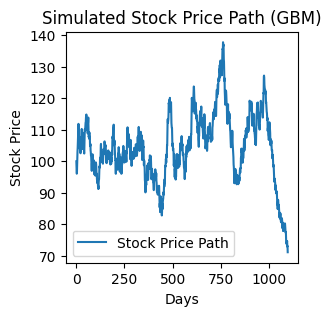

In [ ]:
# 시뮬레이션 횟수 만큼 주가 생성하기
import numpy as np
import matplotlib.pyplot as plt

# 주가 경로 생성
N=df['오늘까지 남은 일수'].iloc[-1] # 만기까지의 날짜수
sim=1000 # 시뮬레이션 회수
r,sigma=0.05, 0.3
dt=1/365

np.random.seed(111)
W = np.random.randn(N,sim)  # 표준 정규분포 난수

# log(S) 행렬 만들기
lnS=(r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W

# 앞에 붙이기
lnS = np.insert(lnS,0,np.log(100), axis=0)
# 누적합 구하기
S=np.exp(np.cumsum(lnS,axis=0))

# 첫번째 시뮬레이션 결과 시각화
plt.figure(figsize=(3,3))
plt.plot(S[:,0], label="Stock Price Path")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.title("Simulated Stock Price Path (GBM)")
plt.legend()
plt.show()

In [ ]:
# 스텝다운 상품 평가 정보
S=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,10000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array(df['오늘까지 남은 일수'])
c=np.array([1,2,3,4,5,6])*0.022

# 주가 경로 생성
N=T[-1] # 만기까지의 날짜수
np.random.seed(111)
W = np.random.randn(N,sim)  # 표준 정규분포 난수
dt=1/365

# log(S) 행렬 만들기
lnS=(r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W

# 앞에 붙이기
lnS = np.insert(lnS,0,np.log(S), axis=0)
# 누적합 구하기
S=np.exp(np.cumsum(lnS,axis=0))

  # 수익률 행렬 변환
R = S / kijun
R.shape

(1099, 10000)

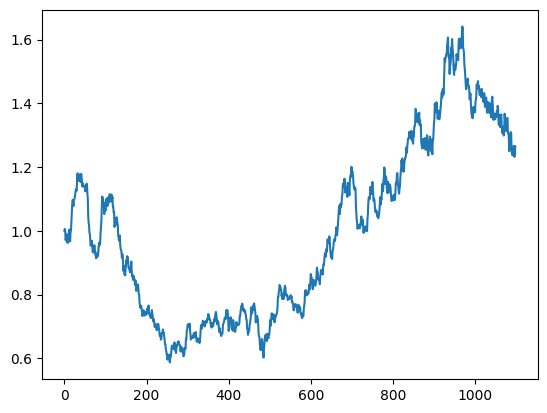

In [ ]:
plt.plot(R[:,1])

In [ ]:
K

[0.95, 0.95, 0.95, 0.9, 0.9, 0.85]

In [ ]:
T

array([ 181,  365,  546,  730,  912, 1098])

In [ ]:
from scipy.stats import norm

Price = np.zeros(sim)  # 최종 옵션 가격 배열

EN=len(K) # 조기상환 회차수
for i in range(EN):
    out = np.where((Price == 0) & (R[T[i], :] >= K[i]))  # 아직 상환되지 않은 경우만 선택
    # 조기상환된 경우 가격 업데이트
    Price[out] = 10000 * (1 + c[i]) * np.exp(-r * (T[i]) / 365)

# 만기상환 테스트
check = np.where(Price == 0) # 아직 상환되지 않은 경우의 인덱스 추출

# 만기 손실 체크
for idx in check:
    if np.min(R[:,idx]) < barrier: # 해당 sim 회차의 최소값이 배리어 미만이면?
        # 배리어 하외 하면 R값으로 리턴
        Price[idx] = 10000 * (R[-1, idx]) * np.exp(-r * T[-1]/365)
    else: # 배리어를 한번도 친적이 없으면 마지막 쿠폰 지급
        Price[idx] = 10000 * (1 + dummy) * np.exp(-r * T[-1]/365)

# 정규분포 적합
mu, s = norm.fit(Price)
mu, s

(np.float64(9198.859724696784), np.float64(2011.7524455685068))

In [ ]:
def SD_lstar_CPU(S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim):
    import numpy as np
    from scipy.stats import norm

    """
    ELS (Equity-Linked Securities) 조기상환 및 만기상환 시뮬레이션

    Parameters:
    - S: 초기 주가
    - kijun: 기준 가격
    - K: 행사가격
    - T: 옵션 만기 (일 단위)
    - c: 조기상환 행사가 (0.01 이상)
    - r: 무위험 이자율
    - q: 배당률
    - sigma: 변동성
    - barrier: 배리어 (예: 65% 미만일 경우 지급)
    - dummy: 배리어 이벤트 여부 (0 또는 1)
    - sim: 시뮬레이션 횟수

    Returns:
    - mu: 최종 가격의 정규분포 적합 결과 (평균, 표준편차)
    """



    # 주가 경로 생성
    N=T[-1] # 만기까지의 날짜수
    np.random.seed(111)
    W = np.random.randn(N,sim)  # 표준 정규분포 난수
    dt=1/365

    # log(S) 행렬 만들기
    lnS=(r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W

    # 앞에 붙이기
    lnS = np.insert(lnS,0,np.log(S), axis=0)
    # 누적합 구하기
    S=np.exp(np.cumsum(lnS,axis=0))

     # 수익률 행렬 변환
    R = S / kijun

    Price = np.zeros(sim)  # 최종 옵션 가격 배열

    EN=len(K) # 조기상환 회차수
    for i in range(EN):
        out = np.where((Price == 0) & (R[T[i], :] >= K[i]))  # 아직 상환되지 않은 경우만 선택
        # 조기상환된 경우 가격 업데이트
        Price[out] = 10000 * (1 + c[i]) * np.exp(-r * (T[i]) / 365)

    # 만기상환 테스트
    check = np.where(Price == 0) # 아직 상환되지 않은 경우의 인덱스 추출

    # 만기 손실 체크
    for idx in check:
        if np.min(R[:,idx]) < barrier: # 해당 sim 회차의 최소값이 배리어 미만이면?
            # 배리어 하외 하면 R값으로 리턴
            Price[idx] = 10000 * (R[-1, idx]) * np.exp(-r * T[-1]/365)
        else: # 배리어를 한번도 친적이 없으면 마지막 쿠폰 지급
            Price[idx] = 10000 * (1 + dummy) * np.exp(-r * T[-1]/365)

    # 정규분포 적합
    mu, s = norm.fit(Price)

    return mu

In [ ]:
# 스텝다운 상품 평가 정보
S0=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,10000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array(df['오늘까지 남은 일수'])
c=np.array([1,2,3,4,5,6])*0.022

SD_lstar_CPU(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

np.float64(9198.859724696784)

In [24]:
def SD_lstar_GPU(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim):
    import cupy as cp
    from scipy.stats import norm  # 정규분포 적합은 여전히 CPU에서 수행
    import numpy as np

    """
    ELS (Equity-Linked Securities) 조기상환 및 만기상환 시뮬레이션 (GPU 버전)
    """

    N = T[-1]  # 전체 만기까지의 날짜 수
    dt = 1 / 365  # 하루 단위
    cp.random.seed(111)
    W = cp.random.randn(N, sim)  # 표준 정규분포 난수 생성

    # 로그 수익률 경로 생성
    lnS = (r - 0.5 * sigma**2) * dt + sigma * cp.sqrt(dt) * W

    # 시작값 log(S0)를 앞에 추가
    lnS = cp.concatenate([cp.full((1, sim), cp.log(S0)), lnS], axis=0)

    # 누적합 후 지수화하여 주가 경로 생성
    S_path = cp.exp(cp.cumsum(lnS, axis=0))

    # 수익률 행렬 계산
    R = S_path / kijun

    # 초기 옵션 가격 배열
    Price = cp.zeros(sim)

    EN = len(K)

    # 조기상환여부 판단
    for i in range(EN):
        # 현재 가격이 0이고, 조기상환일(T[i])의 수익율이 행사가 이상인 인덱스 추출
        cond = (Price == 0) & (R[T[i], :] >= K[i])
        # 해당 인덱스의 값을, 조기상환쿠폰(c[i])으로 상환되며 이를 현재가로 변환
        Price = cp.where(cond, 10000 * (1 + c[i]) * cp.exp(-r * T[i] / 365), Price)

    # 아직 상환되지 않은 시뮬레이션 인덱스 찾기
    check = (Price == 0)

    # 배리어 하회 여부 확인
    min_R = cp.min(R, axis=0) # 각 시뮬레이션에서 최소 수익율 인덱스 추출
    barrier_hit = (min_R < barrier) & check # 미상환된 종목주 최소 수익율일 배리어보다 작은 인덱스 추출
    no_barrier_hit = ~barrier_hit & check # 미상환된 종목주 최소 수익율일 배리어를 터치하지 않은 인덱스 추출

    # 배리어 하회한 경우
    Price = cp.where(barrier_hit, 10000 * R[-1, :] * cp.exp(-r * T[-1] / 365), Price)

    # 배리어를 한 번도 안 맞은 경우
    Price = cp.where(no_barrier_hit, 10000 * (1 + dummy) * cp.exp(-r * T[-1] / 365), Price)

    # GPU에서 CPU로 데이터 이동하여 정규분포 적합
    Price_cpu = cp.asnumpy(Price)
    mu, s = norm.fit(Price_cpu)

    return mu


In [ ]:
import numpy as np
# 스텝다운 상품 평가 정보
S=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,100000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array(df['오늘까지 남은 일수'])
c=np.array([1,2,3,4,5,6])*0.022

SD_lstar_GPU(S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

np.float64(9226.685448101516)

In [1]:
def SD_lstar_GPU_01(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim):
    import cupy as cp
    from scipy.stats import norm  # 정규분포 적합은 여전히 CPU에서 수행
    import numpy as np

    """
    ELS (Equity-Linked Securities) 조기상환 및 만기상환 시뮬레이션 (GPU 버전)
    난수 객체 사용

    """

    N = T[-1]  # 전체 만기까지의 날짜 수
    dt = 1 / 365  # 하루 단위

    # 난수 객체를 이용한 난수 발생
    rng = cp.random.default_rng(111)     # rng 객체 생성
    W = rng.standard_normal((N, sim))    # 표준정규 (randn 대체)

    # 로그 수익률 경로 생성
    lnS = (r - 0.5 * sigma**2) * dt + sigma * cp.sqrt(dt) * W

    # 시작값 log(S0)를 앞에 추가
    lnS = cp.concatenate([cp.full((1, sim), cp.log(S0)), lnS], axis=0)

    # 누적합 후 지수화하여 주가 경로 생성
    S_path = cp.exp(cp.cumsum(lnS, axis=0))

    # 수익률 행렬 계산
    R = S_path / kijun

    # 초기 옵션 가격 배열
    Price = cp.zeros(sim)

    EN = len(K)

    # 조기상환여부 판단
    for i in range(EN):
        # 현재 가격이 0이고, 조기상환일(T[i])의 수익율이 행사가 이상인 인덱스 추출
        cond = (Price == 0) & (R[T[i], :] >= K[i])
        # 해당 인덱스의 값을, 조기상환쿠폰(c[i])으로 상환되며 이를 현재가로 변환
        Price = cp.where(cond, 10000 * (1 + c[i]) * cp.exp(-r * T[i] / 365), Price)

    # 아직 상환되지 않은 시뮬레이션 인덱스 찾기
    check = (Price == 0)

    # 배리어 하회 여부 확인
    min_R = cp.min(R, axis=0) # 각 시뮬레이션에서 최소 수익율 인덱스 추출
    barrier_hit = (min_R < barrier) & check # 미상환된 종목주 최소 수익율일 배리어보다 작은 인덱스 추출
    no_barrier_hit = ~barrier_hit & check # 미상환된 종목주 최소 수익율일 배리어를 터치하지 않은 인덱스 추출

    # 배리어 하회한 경우
    Price = cp.where(barrier_hit, 10000 * R[-1, :] * cp.exp(-r * T[-1] / 365), Price)

    # 배리어를 한 번도 안 맞은 경우
    Price = cp.where(no_barrier_hit, 10000 * (1 + dummy) * cp.exp(-r * T[-1] / 365), Price)

    # GPU에서 CPU로 데이터 이동하여 정규분포 적합
    Price_cpu = cp.asnumpy(Price)
    mu, s = norm.fit(Price_cpu)

    return mu

In [20]:
import numpy as np
# 스텝다운 상품 평가 정보
S=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,100000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array(df['오늘까지 남은 일수'])
c=np.array([1,2,3,4,5,6])*0.022

SD_lstar_GPU_01(S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

np.float64(9231.223633485632)

In [ ]:
import numpy as np

# 스텝다운 상품 평가 정보
S0=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,10000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array(df['오늘까지 남은 일수'])
c=np.array([1,2,3,4,5,6])*0.022

SD_lstar_GPU(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

np.float64(9243.730526160249)

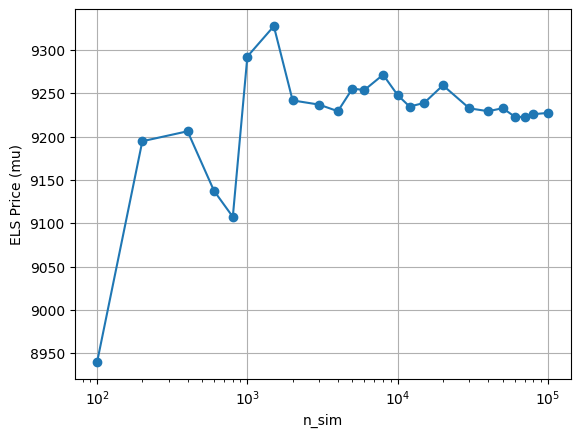

In [25]:
Sims=[100,200,400,600,800,1000,1500,2000,3000,4000,
      5000,6000,8000,10000,12000,15000,20000,30000,
      40000,50000,60000,70000,80000,100000]

Price_Sims=[]
for sim in Sims:
    res=SD_lstar_GPU(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)
    Price_Sims.append(res)

plt.figure()
plt.plot(Sims, Price_Sims, marker='o')
plt.xscale('log')  # 로그스케일로 보면 수렴이 잘 보임
plt.xlabel("n_sim")
plt.ylabel("ELS Price (mu)")
plt.grid(True)
plt.show()

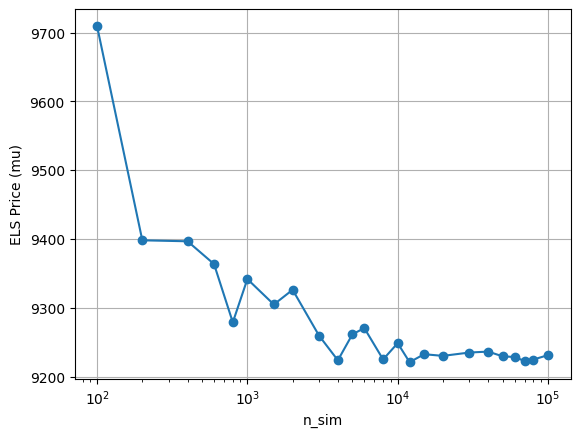

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 스텝다운 상품 평가 정보
S0=100
kijun=100
r=0.035
q=0
sigma, barrier, dummy, sim=0.3, 0.65, 0.132,10000
K=[0.95,0.95,0.95,0.90,0.90,0.85]
T=np.array(df['오늘까지 남은 일수'])
c=np.array([1,2,3,4,5,6])*0.022

Sims=[100,200,400,600,800,1000,1500,2000,3000,4000,
      5000,6000,8000,10000,12000,15000,20000,30000,
      40000,50000,60000,70000,80000,100000]

Price_Sims=[]
for sim in Sims:
    res=SD_lstar_GPU_01(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)
    Price_Sims.append(res)

plt.figure()
plt.plot(Sims, Price_Sims, marker='o')
plt.xscale('log')  # 로그스케일로 보면 수렴이 잘 보임
plt.xlabel("n_sim")
plt.ylabel("ELS Price (mu)")
plt.grid(True)
plt.show()

In [21]:
def MC_Greeks_SD1(fun, S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim):
    # Delta (Δ)
    eps=S*sigma*0.01
    C_plus = fun(S + eps, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)
    C_minus = fun(S - eps, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)
    Delta = (C_plus - C_minus) / (2 * eps)
    # Gamma (Γ)
    C_0 = fun(S,kijun, K, T, c, r, q, sigma, barrier, dummy, sim)
    Gamma = (C_plus - 2 * C_0 + C_minus) / (eps ** 2)
    # Vega (V)
    eps=sigma*0.01
    C_sigma_plus = fun(S, kijun, K, T, c, r, q, sigma+eps, barrier, dummy, sim)
    C_sigma_minus = fun(S, kijun, K, T, c, r, q, sigma-eps, barrier, dummy, sim)
    Vega = (C_sigma_plus - C_sigma_minus) / (2 * eps)
    Vega = 0.01*Vega # 1% 베가로 변환
    # 1day Theta (Θ)
    eps=1 # T가 날짜 수임으로 수정
    C_t = fun(S, kijun, K, T-eps, c, r, q, sigma, barrier, dummy, sim)
    Theta = (C_t - C_0) # 날짜가 하루 줄어든 것이므로 그대로
    # 1bp Rho (ρ)
    C_r_plus = fun(S, kijun, K, T, c, r+eps, q, sigma+eps, barrier, dummy, sim)
    C_r_minus = fun(S, kijun, K, T, c, r-eps, q, sigma+eps, barrier, dummy, sim)
    Rho = 0.0001* (C_r_plus - C_r_minus) / (2 * eps)
    return {
        "Price": C_0,
        "Delta (Δ)": Delta,
        "Gamma (Γ)": Gamma,
        "Theta (Θ)": Theta,
        "Vega (V)": Vega,
        "Rho (ρ)": Rho,
    }

In [26]:
MC_Greeks_SD1(SD_lstar_GPU,S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': np.float64(9227.376773103222),
 'Delta (Δ)': np.float64(44.22904156319722),
 'Gamma (Γ)': np.float64(-8.683193491116173),
 'Theta (Θ)': np.float64(1.7625174549848452),
 'Vega (V)': np.float64(-43.00660097657176),
 'Rho (ρ)': np.float64(-0.15451865777946727)}

In [22]:
MC_Greeks_SD1(SD_lstar_GPU_01,S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': np.float64(9231.223633485632),
 'Delta (Δ)': np.float64(46.43036798335137),
 'Gamma (Γ)': np.float64(17.225072946004932),
 'Theta (Θ)': np.float64(4.018652967499293),
 'Vega (V)': np.float64(-43.95254835903263),
 'Rho (ρ)': np.float64(-0.15329952857756968)}

# CRN(Common Random Numbers) 사용: 발생된 난수의 재활용

In [25]:
def SD_lstar_GPU_CRN(
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    Z=None, return_Z=False, notional=10000.0, dtype="float64"
):
    import cupy as cp
    import numpy as np

    # --- T를 무조건 1D로 강제 (핵심 수정) ---
    T_np = np.atleast_1d(np.asarray(T, dtype=int))
    if T_np.size == 0:
        raise ValueError("T가 비어 있습니다.")
    if np.any(T_np < 0):
        raise ValueError("T에는 음수(일 인덱스)가 있으면 안 됩니다.")

    # K, c도 1D로 강제
    K_np = np.atleast_1d(np.asarray(K, dtype=float))
    c_np = np.atleast_1d(np.asarray(c, dtype=float))
    if not (len(K_np) == len(T_np) == len(c_np)):
        raise ValueError(f"K, T, c 길이가 달라요. len(K)={len(K_np)}, len(T)={len(T_np)}, len(c)={len(c_np)}")

    K_cp = cp.asarray(K_np, dtype=cp.float64)
    c_cp = cp.asarray(c_np, dtype=cp.float64)

    # ---- Z 준비 (CRN) ----
    if Z is None:
        N = int(T_np[-1])
        if N <= 0:
            raise ValueError("T[-1] (만기일)은 양의 정수(일)여야 합니다.")

        cp.random.seed(seed)
        dtype_cp = cp.float64 if dtype == "float64" else cp.float32

        if antithetic:
            half = (sim + 1) // 2
            Z_half = cp.random.standard_normal((N, half), dtype=dtype_cp)
            Z = cp.concatenate([Z_half, -Z_half], axis=1)[:, :sim]
        else:
            Z = cp.random.standard_normal((N, sim), dtype=dtype_cp)
    else:
        if not hasattr(Z, "shape") or len(Z.shape) != 2:
            raise ValueError("Z는 (N, sim) 형태의 2D 배열이어야 합니다.")
        N, sim_Z = Z.shape
        sim = sim_Z
        if T_np[-1] > N:
            raise ValueError(f"T[-1]={T_np[-1]}가 Z의 N={N}보다 큽니다. Z를 더 길게 생성하세요.")

    # ---- GBM 경로 ----
    dt = 1.0 / 365.0
    drift = (r - q - 0.5 * sigma**2) * dt
    vol = sigma * cp.sqrt(dt)

    lnS = drift + vol * Z
    lnS0 = cp.full((1, sim), cp.log(S0), dtype=cp.float64)
    lnS = cp.concatenate([lnS0, lnS], axis=0)

    S_path = cp.exp(cp.cumsum(lnS, axis=0))
    R = S_path / kijun

    # ---- 조기상환 ----
    Price = cp.zeros(sim, dtype=cp.float64)
    EN = len(T_np)

    for i in range(EN - 1):
        t = int(T_np[i])
        alive = (Price == 0.0)
        hit = alive & (R[t, :] >= K_cp[i])
        Price = cp.where(hit, notional * (1.0 + c_cp[i]) * cp.exp(-r * t / 365.0), Price)

    # ---- 만기상환 ----
    alive = (Price == 0.0)
    if cp.any(alive):
        min_R = cp.min(R[:, alive], axis=0)
        ki_hit = (min_R < barrier)

        t_mat = int(T_np[-1])
        payoff_ki = notional * R[t_mat, alive] * cp.exp(-r * t_mat / 365.0)
        payoff_no = notional * (1.0 + dummy) * cp.exp(-r * t_mat / 365.0)

        Price_alive = cp.where(ki_hit, payoff_ki, payoff_no)
        Price[alive] = Price_alive

    mu = float(cp.mean(Price).get())
    if return_Z:
        return mu, Z
    return mu


In [30]:
SD_lstar_GPU_CRN(S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

9206.17872005907

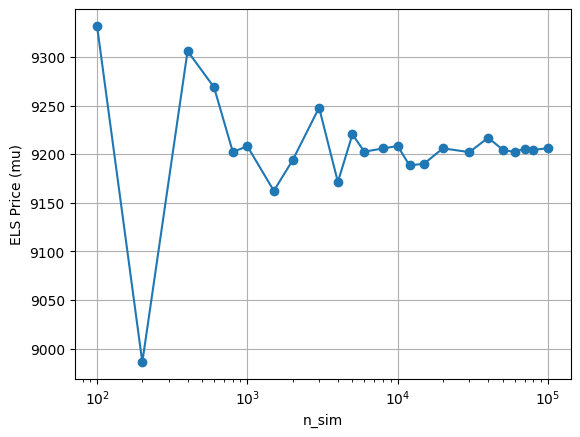

In [31]:
Sims=[100,200,400,600,800,1000,1500,2000,3000,4000,
      5000,6000,8000,10000,12000,15000,20000,30000,
      40000,50000,60000,70000,80000,100000]

Price_Sims=[]
for sim in Sims:
    res=SD_lstar_GPU_CRN(S0, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)
    Price_Sims.append(res)

plt.figure()
plt.plot(Sims, Price_Sims, marker='o')
plt.xscale('log')  # 로그스케일로 보면 수렴이 잘 보임
plt.xlabel("n_sim")
plt.ylabel("ELS Price (mu)")
plt.grid(True)
plt.show()

In [23]:
import numpy as np

def MC_Greeks_SD1_GPU_CRN(
    pricer,  # SD_lstar_GPU_CRN
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    bump_S_frac=0.01,      # eps_S = S0*sigma*bump_S_frac
    bump_sigma_frac=0.01,  # eps_sigma = sigma*bump_sigma_frac
    bump_r_bp=1            # 1bp
):
    """
    SD_lstar_GPU_CRN을 이용한 CRN Greeks (1자산 StepDown)
    - pricer는 (return_Z=True)로 Z를 반환할 수 있어야 하고,
      이후 호출에서 Z를 입력받아 재사용할 수 있어야 함.
    """

    # T는 최소 1D로 강제 (스칼라 방지)
    T = np.atleast_1d(np.asarray(T, dtype=int))

    # ---- 0) CRN용 Z를 1회 생성하며 base price 계산 ----
    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype
    )

    # ---- 1) Delta/Gamma ----
    eps_S = S0 * sigma * bump_S_frac
    if eps_S == 0:
        eps_S = 1e-12  # 방어

    Cp = pricer(
        S0 + eps_S, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cm = pricer(
        S0 - eps_S, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Delta = (Cp - Cm) / (2.0 * eps_S)
    Gamma = (Cp - 2.0 * C0 + Cm) / (eps_S ** 2)

    # ---- 2) Vega (1% Vega) ----
    eps_sig = sigma * bump_sigma_frac
    if eps_sig == 0:
        eps_sig = 1e-12  # 방어

    Csig_p = pricer(
        S0, kijun, K, T, c, r, q, sigma + eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Csig_m = pricer(
        S0, kijun, K, T, c, r, q, sigma - eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Vega = (Csig_p - Csig_m) / (2.0 * eps_sig)
    Vega_1pct = 0.01 * Vega  # 1% vega로 스케일

    # ---- 3) Theta (1-day) : 모든 날짜를 1일 당김 ----
    Tm = T.copy()
    Tm = np.maximum(T - 1, 0)

    Ct = pricer(
        S0, kijun, K, Tm, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Theta_1d = Ct - C0

    # ---- 4) Rho (1bp) ----
    eps_r = bump_r_bp * 0.0001

    Cr_p = pricer(
        S0, kijun, K, T, c, r + eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cr_m = pricer(
        S0, kijun, K, T, c, r - eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Rho_per_unit = (Cr_p - Cr_m) / (2.0 * eps_r)
    Rho_1bp = 0.0001 * Rho_per_unit  # 1bp 민감도

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_S": eps_S,
            "eps_sigma": eps_sig,
            "eps_r": eps_r,
            "CRN": True,
            "antithetic": antithetic,
            "seed": seed,
        }
    }


In [33]:
MC_Greeks_SD1_GPU_CRN(SD_lstar_GPU_CRN,S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': 9206.17872005907,
 'Delta': 47.20131113608962,
 'Gamma': 20.209148416183275,
 'Vega(1%)': -42.43068206658488,
 'Theta(1d)': 4.93331375217349,
 'Rho(1bp)': -0.42305511955601105,
 'bump': {'eps_S': 0.3,
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111}}

In [35]:
MC_Greeks_SD1(SD_lstar_GPU_01,S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': np.float64(9231.223633485632),
 'Delta (Δ)': np.float64(46.43036798335137),
 'Gamma (Γ)': np.float64(17.225072946004932),
 'Theta (Θ)': np.float64(4.018652967499293),
 'Vega (V)': np.float64(-43.95254835903263),
 'Rho (ρ)': np.float64(-0.15329952857756968)}

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def verify_gamma_convexity(
    pricer,                       # SD_lstar_GPU_CRN 같은 인터페이스
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim=10000, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    width=0.05, n_grid=21,
    compare_noncrn=True,          # 비-CRN(매번 새 난수) 곡선도 같이 그릴지
    noncrn_seed_base=1000         # 비-CRN seed 시작값
):
    """
    Gamma 부호 검증용:
    - S를 여러 점(S-grid)에서 가격을 계산하고
    - 가격곡선의 2차 미분(중앙차분)으로 Gamma의 부호/형태를 확인

    요구사항(pricer):
    - pricer(..., Z=None, return_Z=True) -> (price, Z) 반환 가능
    - pricer(..., Z=Z, return_Z=False) -> price 반환 가능
    """

    T = np.atleast_1d(np.asarray(T, dtype=int))

    # S-grid 생성 (S0*(1-width) ~ S0*(1+width))
    S_grid = S0 * np.linspace(1 - width, 1 + width, n_grid)

    # -----------------------------
    # 1) CRN 곡선: 같은 Z를 재사용
    # -----------------------------
    base_price, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim
    ,   seed=seed, antithetic=antithetic, Z=None, return_Z=True,
        notional=notional, dtype=dtype
    )

    prices_crn = np.empty(n_grid, dtype=float)
    for i, S in enumerate(S_grid):
        prices_crn[i] = pricer(
            float(S), kijun, K, T, c, r, q, sigma, barrier, dummy,
            sim=sim
        ,   seed=seed, antithetic=antithetic, Z=Z, return_Z=False,
            notional=notional, dtype=dtype
        )

    # 중앙차분으로 Gamma 근사 (S가 균등격자일 때)
    dS = S_grid[1] - S_grid[0]
    gamma_crn = np.full(n_grid, np.nan, dtype=float)
    gamma_crn[1:-1] = (prices_crn[2:] - 2 * prices_crn[1:-1] + prices_crn[:-2]) / (dS ** 2)

    # -----------------------------
    # 2) Non-CRN 곡선: 매 S마다 다른 난수(또는 seed 변경)
    # -----------------------------
    prices_non = None
    gamma_non = None
    if compare_noncrn:
        prices_non = np.empty(n_grid, dtype=float)
        for i, S in enumerate(S_grid):
            # 매번 다른 seed로 Z 생성(=비-CRN)
            prices_non[i] = pricer(
                float(S), kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim
            ,   seed=noncrn_seed_base + i, antithetic=antithetic, Z=None, return_Z=False,
                notional=notional, dtype=dtype
            )

        gamma_non = np.full(n_grid, np.nan, dtype=float)
        gamma_non[1:-1] = (prices_non[2:] - 2 * prices_non[1:-1] + prices_non[:-2]) / (dS ** 2)

    # -----------------------------
    # 3) 시각화: Price curve & Gamma curve
    # -----------------------------
    fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

    # Price curve
    axes[0].plot(S_grid, prices_crn, label="Price (CRN, same Z)")
    axes[0].axvline(S0, linestyle="--", alpha=0.6)
    if compare_noncrn:
        axes[0].plot(S_grid, prices_non, label="Price (non-CRN, new Z each S)", alpha=0.8)
    axes[0].set_ylabel("Price")
    axes[0].set_title("Price vs Underlying (Convexity check via 2nd derivative)")
    axes[0].grid(True)
    axes[0].legend()

    # Gamma curve (2nd derivative)
    axes[1].plot(S_grid, gamma_crn, label="Gamma approx (CRN)")
    axes[1].axhline(0.0, linestyle="--", alpha=0.6)
    axes[1].axvline(S0, linestyle="--", alpha=0.6)
    if compare_noncrn:
        axes[1].plot(S_grid, gamma_non, label="Gamma approx (non-CRN)", alpha=0.8)
    axes[1].set_xlabel("Underlying S")
    axes[1].set_ylabel("Gamma (2nd finite diff)")
    axes[1].grid(True)
    axes[1].legend()

    plt.show()

    # -----------------------------
    # 4) 간단 요약 출력: S0 주변 Gamma 부호
    # -----------------------------
    mid = np.argmin(np.abs(S_grid - S0))
    # 중앙차분은 mid가 양끝이면 NaN이라, 안전하게 mid를 내부로 보정
    mid = np.clip(mid, 1, n_grid - 2)

    print("[CRN] S0 근처 Gamma =", gamma_crn[mid])
    if compare_noncrn:
        print("[non-CRN] S0 근처 Gamma =", gamma_non[mid])

    return {
        "S_grid": S_grid,
        "prices_crn": prices_crn,
        "gamma_crn": gamma_crn,
        "prices_noncrn": prices_non if compare_noncrn else None,
        "gamma_noncrn": gamma_non if compare_noncrn else None,
        "Z": Z,  # 필요 시 재사용/디버깅
    }




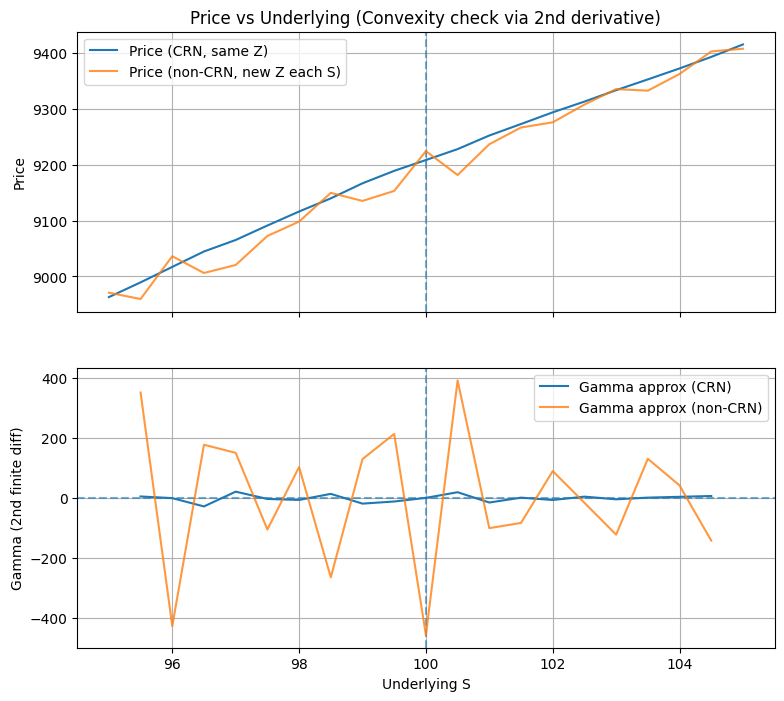

[CRN] S0 근처 Gamma = 0.5378205799352145
[non-CRN] S0 근처 Gamma = -455.88002892069926


{'S_grid': array([ 95. ,  95.5,  96. ,  96.5,  97. ,  97.5,  98. ,  98.5,  99. ,
         99.5, 100. , 100.5, 101. , 101.5, 102. , 102.5, 103. , 103.5,
        104. , 104.5, 105. ]),
 'prices_crn': array([8963.05304705, 8989.45526722, 9017.14541839, 9044.73027376,
        9065.31754352, 9091.1983506 , 9116.29865247, 9139.80165592,
        9166.75979649, 9189.05043896, 9208.43686083, 9227.95773784,
        9252.29711446, 9272.88340282, 9293.76275239, 9313.0137141 ,
        9333.40165313, 9352.71497394, 9372.34883295, 9392.97584069,
        9415.27249664]),
 'gamma_crn': array([         nan,   5.15172402,  -0.42118319, -27.99034244,
         21.17414924,  -3.1220208 ,  -6.38919369,  13.82054848,
        -18.66999241, -11.6168824 ,   0.53782058,  19.27399843,
        -15.01235302,   1.17224481,  -6.51355145,   4.5479093 ,
         -4.29847286,   1.2821528 ,   3.97259489,   6.67859284,
                 nan]),
 'prices_noncrn': array([8970.94567183, 8959.70792407, 9036.24568383, 9006.258088

In [37]:
verify_gamma_convexity(
    pricer=SD_lstar_GPU_CRN,
    S0=S, kijun=kijun, K=K, T=T, c=c,
    r=r, q=q, sigma=sigma, barrier=barrier, dummy=dummy,
    sim=10000, seed=111, antithetic=True,
    width=0.05, n_grid=21,
    compare_noncrn=True
)

In [38]:
# bump size 변경에 따른 Gamma 값의 안정화 구간 찾기

import numpy as np

def gamma_bump_stability_test(
    pricer,
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim=10000, seed=111, antithetic=True,
    bump_list=(0.002, 0.005, 0.01, 0.02, 0.05),
    notional=10000.0, dtype="float64"
):
    """
    Gamma bump 안정성 테스트 (CRN)
    - 같은 Z를 고정한 채 bump 크기만 변화
    """

    T = np.atleast_1d(np.asarray(T, dtype=int))

    # ---- 기준 Z 한 번 생성 ----
    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype
    )

    results = []

    for bump in bump_list:
        eps_S = S0 * sigma * bump
        eps_S = max(eps_S, 1e-12)

        Cp = pricer(
            S0 + eps_S, kijun, K, T, c, r, q, sigma, barrier, dummy,
            sim=sim, Z=Z, return_Z=False,
            notional=notional, dtype=dtype
        )
        Cm = pricer(
            S0 - eps_S, kijun, K, T, c, r, q, sigma, barrier, dummy,
            sim=sim, Z=Z, return_Z=False,
            notional=notional, dtype=dtype
        )

        gamma = (Cp - 2.0 * C0 + Cm) / (eps_S ** 2)

        results.append({
            "bump_S_frac": bump,
            "eps_S": eps_S,
            "Gamma": gamma
        })

    return results


In [39]:
gamma_table = gamma_bump_stability_test(
    pricer=SD_lstar_GPU_CRN,
    S0=S, kijun=kijun, K=K, T=T, c=c,
    r=r, q=q, sigma=sigma,
    barrier=barrier, dummy=dummy,
    sim=10000,
    bump_list=[0.002, 0.005, 0.01, 0.02, 0.05]
)

for row in gamma_table:
    print(row)


{'bump_S_frac': 0.002, 'eps_S': 0.06, 'Gamma': 116.67295198700837}
{'bump_S_frac': 0.005, 'eps_S': 0.15, 'Gamma': -25.154211376502644}
{'bump_S_frac': 0.01, 'eps_S': 0.3, 'Gamma': -20.77660302784352}
{'bump_S_frac': 0.02, 'eps_S': 0.6, 'Gamma': 0.21089258480565656}
{'bump_S_frac': 0.05, 'eps_S': 1.5, 'Gamma': -1.8616279594660026}


In [28]:
# 감마 값 스무딩 Greeks

import numpy as np

def MC_Greeks_SD1_GPU_CRN_01(
    pricer,  # SD_lstar_GPU_CRN
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    bump_S_frac=0.01,      # (기본) eps_base = S0 * bump_S_frac   (감마 스무딩용 권장)
    bump_sigma_frac=0.01,  # eps_sigma = sigma*bump_sigma_frac
    bump_r_bp=1,           # 1bp
    # ---- Gamma smoothing (NEW) ----
    gamma_smooth=True,
    gamma_mults=(0.5, 1.0, 2.0, 4.0, 8.0),   # 다점 bump 배수 (계산비용 vs 안정성 트레이드오프)
    gamma_agg="median",                # "median" or "trimmed_mean"
    gamma_trim=0.25                    # trimmed_mean일 때 상/하위 trim 비율(0~0.49)
):
    """
    SD_lstar_GPU_CRN을 이용한 CRN Greeks (1자산 StepDown)
    - 가격(pricer)은 그대로(불연속 유지)
    - 감마만: 다점 bump + 로버스트 집계로 안정화
    """

    # ---- 0) 입력 정리 ----
    T = np.atleast_1d(np.asarray(T, dtype=int))

    # ---- 1) CRN용 Z를 1회 생성 + base price ----
    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype
    )

    # ----------------------------
    # 2) Delta / Gamma
    # ----------------------------
    # (A) Delta는 기존 중앙차분 1회
    # 기존 정의 유지:
    eps_S_delta = S0 * sigma * bump_S_frac
    # 감마 전용으로 eps를 다르게 쓰고 싶으면 아래처럼 분리 가능
    # eps_S_delta = S0 * bump_S_frac

    if eps_S_delta == 0:
        eps_S_delta = 1e-12

    Cp = pricer(
        S0 + eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cm = pricer(
        S0 - eps_S_delta, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Delta = (Cp - Cm) / (2.0 * eps_S_delta)

    # (B) Gamma는 스무딩(다점 bump + median/trimmed mean)
    if not gamma_smooth: # 감마 스무딩을 안할거면
        Gamma = (Cp - 2.0 * C0 + Cm) / (eps_S_delta ** 2)
    else: # 감마 스미딩을 할거면
        # 감마용 eps_base는 sigma를 곱하지 않는 게 보통 더 안정적 (추천)
        eps_base = S0 * bump_S_frac
        # 만약 네 기존 정의를 그대로 쓰고 싶으면:
        # eps_base = S0 * sigma * bump_S_frac

        if eps_base == 0:
            eps_base = 1e-12

        gammas = []
        for m in gamma_mults:
            eps = float(eps_base * m)
            if eps == 0:
                continue

            Cp_g = pricer(
                S0 + eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
            )
            Cm_g = pricer(
                S0 - eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
                sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
            )
            gammas.append((Cp_g - 2.0 * C0 + Cm_g) / (eps * eps))

        if len(gammas) == 0:
            Gamma = np.nan
        else:
            gammas = np.asarray(gammas, dtype=float)

            if gamma_agg == "median":
                Gamma = float(np.median(gammas))
            elif gamma_agg == "trimmed_mean":
                # 상/하위 trim 후 평균
                trim = float(gamma_trim)
                trim = max(0.0, min(trim, 0.49))
                g_sorted = np.sort(gammas)
                n = len(g_sorted)
                k = int(np.floor(trim * n))
                core = g_sorted[k:n - k] if (n - 2 * k) >= 1 else g_sorted
                Gamma = float(np.mean(core))
            else:
                raise ValueError("gamma_agg는 'median' 또는 'trimmed_mean'만 지원합니다.")

    # ----------------------------
    # 3) Vega (1% Vega)
    # ----------------------------
    eps_sig = sigma * bump_sigma_frac
    if eps_sig == 0:
        eps_sig = 1e-12

    Csig_p = pricer(
        S0, kijun, K, T, c, r, q, sigma + eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Csig_m = pricer(
        S0, kijun, K, T, c, r, q, sigma - eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Vega = (Csig_p - Csig_m) / (2.0 * eps_sig)
    Vega_1pct = 0.01 * Vega

    # ----------------------------
    # 4) Theta (1-day): 모든 날짜를 1일 당김
    # ----------------------------
    Tm = np.maximum(T - 1, 0)

    Ct = pricer(
        S0, kijun, K, Tm, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Theta_1d = Ct - C0

    # ----------------------------
    # 5) Rho (1bp)
    # ----------------------------
    eps_r = bump_r_bp * 0.0001

    Cr_p = pricer(
        S0, kijun, K, T, c, r + eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cr_m = pricer(
        S0, kijun, K, T, c, r - eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )

    Rho_per_unit = (Cr_p - Cr_m) / (2.0 * eps_r)
    Rho_1bp = 0.0001 * Rho_per_unit

    return {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_S_delta": eps_S_delta,
            "eps_S_gamma_base": (S0 * bump_S_frac) if gamma_smooth else eps_S_delta,
            # 위 줄에서 eps_base 정의를 sigma 포함으로 바꾸면 같이 바꿔주면 됨
            "eps_sigma": eps_sig,
            "eps_r": eps_r,
            "CRN": True,
            "antithetic": antithetic,
            "seed": seed,
            "gamma_smooth": gamma_smooth,
            "gamma_mults": tuple(gamma_mults),
            "gamma_agg": gamma_agg,
        }
    }


In [26]:
MC_Greeks_SD1_GPU_CRN(SD_lstar_GPU_CRN,S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': 9206.17872005907,
 'Delta': 47.20131113608962,
 'Gamma': 20.209148416183275,
 'Vega(1%)': -42.43068206658488,
 'Theta(1d)': 4.93331375217349,
 'Rho(1bp)': -0.42305511955601105,
 'bump': {'eps_S': 0.3,
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111}}

In [29]:
MC_Greeks_SD1_GPU_CRN_01(SD_lstar_GPU_CRN,S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': 9206.17872005907,
 'Delta': 47.20131113608962,
 'Gamma': -1.4215055398030927,
 'Vega(1%)': -42.43068206658488,
 'Theta(1d)': 4.93331375217349,
 'Rho(1bp)': -0.42305511955601105,
 'bump': {'eps_S_delta': 0.3,
  'eps_S_gamma_base': 1.0,
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111,
  'gamma_smooth': True,
  'gamma_mults': (0.5, 1.0, 2.0, 4.0, 8.0),
  'gamma_agg': 'median'}}

In [30]:
import numpy as np

seeds = [11, 22, 33, 44, 55, 66, 77, 88, 99, 111]

gamma_plain = []
gamma_smooth = []

for sd in seeds:
    # A) 기존(스무딩 off)
    outA = MC_Greeks_SD1_GPU_CRN_01(
        SD_lstar_GPU_CRN, S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=sd, antithetic=True,
        bump_S_frac=0.01,
        gamma_smooth=False,      # <- 기존 감마
    )
    gamma_plain.append(outA["Gamma"])

    # B) 스무딩 on (median)
    outB = MC_Greeks_SD1_GPU_CRN_01(
        SD_lstar_GPU_CRN, S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=sd, antithetic=True,
        bump_S_frac=0.01,
        gamma_smooth=True,
        gamma_mults=(0.5,1.0,2.0,4.0,8),
        gamma_agg="median",
    )
    gamma_smooth.append(outB["Gamma"])

gamma_plain = np.array(gamma_plain, float)
gamma_smooth = np.array(gamma_smooth, float)

print("plain  mean/std:", gamma_plain.mean(), gamma_plain.std(ddof=1))
print("smooth mean/std:", gamma_smooth.mean(), gamma_smooth.std(ddof=1))
print("std ratio (smooth/plain):", gamma_smooth.std(ddof=1)/gamma_plain.std(ddof=1))


plain  mean/std: -0.39630405255997586 12.86718369023605
smooth mean/std: -1.876712137289968 0.8959888818277031
std ratio (smooth/plain): 0.06963364349166808


In [33]:
# 델타, 감마 동시 스무딩

import numpy as np

def MC_Greeks_SD1_GPU_CRN_02(
    pricer,  # SD_lstar_GPU_CRN
    S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
    sim, seed=111, antithetic=True,
    notional=10000.0, dtype="float64",
    bump_S_frac=0.01,      # (권장) eps_base = S0 * bump_S_frac (Delta/Gamma용 공통)
    bump_sigma_frac=0.01,  # eps_sigma = sigma*bump_sigma_frac
    bump_r_bp=1,           # 1bp

    # ---- Delta/Gamma robust smoothing (NEW) ----
    dg_smooth=True,
    dg_mults=(0.5, 1.0, 2.0, 4.0, 8.0),      # eps 배수들
    dg_agg="trimmed_mean",                    # "median" or "trimmed_mean"
    dg_trim=0.25,                       # trimmed_mean일 때만 사용(0~0.49)
    return_candidates=False              # True면 Delta/Gamma 후보도 같이 반환
):
    """
    SD_lstar_GPU_CRN을 이용한 CRN Greeks (1자산 StepDown)

    핵심 변경:
    - Delta도 Gamma처럼 "여러 eps에서 후보를 만들고" median/trimmed_mean으로 집계
    - Gamma 후보 계산에 필요한 Cp/Cm를 재사용하므로 추가 비용 최소(멀티 eps에서 Cp/Cm만 계산)
    - 가격(pricer)은 그대로(불연속 payoff 유지) => 가격 바이어스 없음
    """

    # ---- 0) 입력 정리 ----
    T = np.atleast_1d(np.asarray(T, dtype=int))

    # ---- 1) CRN용 Z 1회 생성 + base price ----
    C0, Z = pricer(
        S0, kijun, K, T, c, r, q, sigma, barrier, dummy,
        sim=sim, seed=seed, antithetic=antithetic,
        Z=None, return_Z=True, notional=notional, dtype=dtype
    )

    # ----------------------------
    # 2) Delta / Gamma (robust)
    # ----------------------------
    # eps_base: (권장) sigma를 곱하지 말고 S0 스케일로 고정하는 게 더 안정적인 경우가 많음
    eps_base = float(S0 * bump_S_frac)
    if eps_base == 0.0:
        eps_base = 1e-12

    delta_cands = []
    gamma_cands = []

    # dg_smooth=False면 mults 중 1.0 하나만 쓰도록 처리(기존 3점 단일 bump과 동일)
    mults = dg_mults if dg_smooth else (1.0,)

    for m in mults:
        eps = float(eps_base * m)
        if eps == 0.0:
            continue

        Cp = pricer(
            S0 + eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
            sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
        )
        Cm = pricer(
            S0 - eps, kijun, K, T, c, r, q, sigma, barrier, dummy,
            sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
        )

        delta_cands.append((Cp - Cm) / (2.0 * eps))
        gamma_cands.append((Cp - 2.0 * C0 + Cm) / (eps * eps))

    if len(delta_cands) == 0:
        Delta = np.nan
        Gamma = np.nan
    else:
        delta_cands = np.asarray(delta_cands, dtype=float)
        gamma_cands = np.asarray(gamma_cands, dtype=float)

        if dg_agg == "median":
            Delta = float(np.median(delta_cands))
            Gamma = float(np.median(gamma_cands))
        elif dg_agg == "trimmed_mean":
            trim = float(dg_trim)
            trim = max(0.0, min(trim, 0.49))

            # Delta trimmed mean
            d_sorted = np.sort(delta_cands)
            n = len(d_sorted)
            k = int(np.floor(trim * n))
            d_core = d_sorted[k:n - k] if (n - 2 * k) >= 1 else d_sorted
            Delta = float(np.mean(d_core))

            # Gamma trimmed mean
            g_sorted = np.sort(gamma_cands)
            n2 = len(g_sorted)
            k2 = int(np.floor(trim * n2))
            g_core = g_sorted[k2:n2 - k2] if (n2 - 2 * k2) >= 1 else g_sorted
            Gamma = float(np.mean(g_core))
        else:
            raise ValueError("dg_agg는 'median' 또는 'trimmed_mean'만 지원합니다.")

    # ----------------------------
    # 3) Vega (1% Vega)
    # ----------------------------
    eps_sig = float(sigma * bump_sigma_frac)
    if eps_sig == 0.0:
        eps_sig = 1e-12

    Csig_p = pricer(
        S0, kijun, K, T, c, r, q, sigma + eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Csig_m = pricer(
        S0, kijun, K, T, c, r, q, sigma - eps_sig, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Vega = (Csig_p - Csig_m) / (2.0 * eps_sig)
    Vega_1pct = 0.01 * Vega

    # ----------------------------
    # 4) Theta (1-day): 모든 날짜를 1일 당김
    # ----------------------------
    Tm = np.maximum(T - 1, 0)
    Ct = pricer(
        S0, kijun, K, Tm, c, r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Theta_1d = Ct - C0

    # ----------------------------
    # 5) Rho (1bp)
    # ----------------------------
    eps_r = float(bump_r_bp * 0.0001)

    Cr_p = pricer(
        S0, kijun, K, T, c, r + eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Cr_m = pricer(
        S0, kijun, K, T, c, r - eps_r, q, sigma, barrier, dummy,
        sim=sim, Z=Z, return_Z=False, notional=notional, dtype=dtype
    )
    Rho_per_unit = (Cr_p - Cr_m) / (2.0 * eps_r)
    Rho_1bp = 0.0001 * Rho_per_unit

    out = {
        "Price": C0,
        "Delta": Delta,
        "Gamma": Gamma,
        "Vega(1%)": Vega_1pct,
        "Theta(1d)": Theta_1d,
        "Rho(1bp)": Rho_1bp,
        "bump": {
            "eps_base(S)": eps_base,
            "mults": tuple(mults),
            "eps_sigma": eps_sig,
            "eps_r": eps_r,
            "CRN": True,
            "antithetic": antithetic,
            "seed": seed,
            "dg_smooth": dg_smooth,
            "dg_agg": dg_agg,
            "dg_trim": dg_trim if dg_agg == "trimmed_mean" else None,
        }
    }

    if return_candidates:
        out["Delta_candidates"] = delta_cands.tolist() if len(delta_cands) else []
        out["Gamma_candidates"] = gamma_cands.tolist() if len(gamma_cands) else []

    return out


In [34]:
MC_Greeks_SD1_GPU_CRN_02(SD_lstar_GPU_CRN,S, kijun, K, T, c, r, q, sigma, barrier, dummy, sim)

{'Price': 9206.17872005907,
 'Delta': 47.08611079739194,
 'Gamma': -0.7174584747094741,
 'Vega(1%)': -42.43068206658488,
 'Theta(1d)': 4.93331375217349,
 'Rho(1bp)': -0.42305511955601105,
 'bump': {'eps_base(S)': 1.0,
  'mults': (0.5, 1.0, 2.0, 4.0, 8.0),
  'eps_sigma': 0.003,
  'eps_r': 0.0001,
  'CRN': True,
  'antithetic': True,
  'seed': 111,
  'dg_smooth': True,
  'dg_agg': 'trimmed_mean',
  'dg_trim': 0.25}}